## > EDA : Exploratory Data Analysis and Visualization

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
sns.set_style('white')
plt.rcParams["figure.figsize"]=(10,5)
df = pd.read_csv('../data/processed/cleaned_listings.csv')
print(f"Loaded {len(df)} records for EDA")

Loaded 12359 records for EDA


## 1. Price Distribution

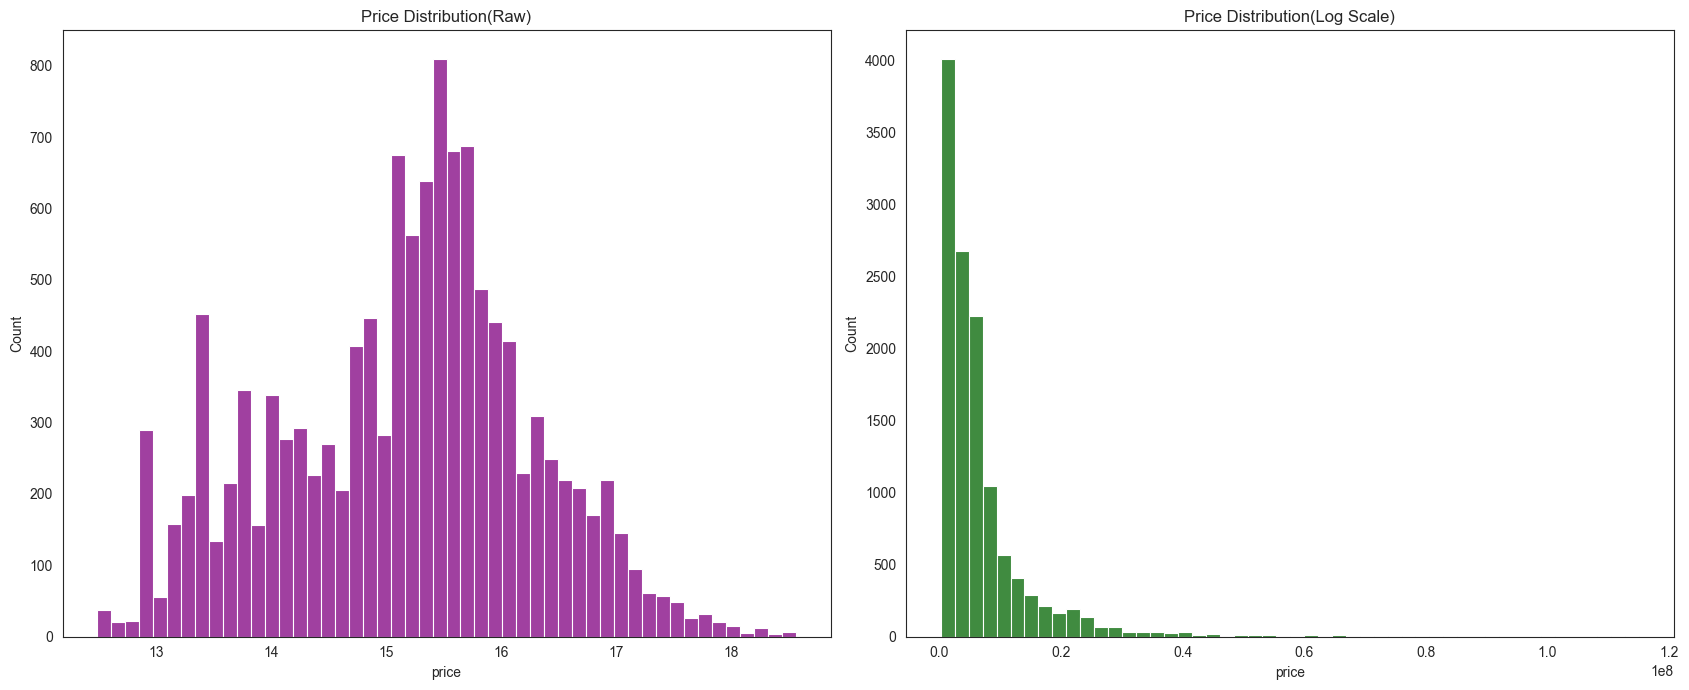

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
sns.histplot(np.log1p(df["price"]), bins=50, ax=axes[0], color="purple")
axes[1].set_title("Price Distribution(Log Scale)")
sns.histplot(df["price"], bins=50, ax=axes[1], color="darkgreen")
axes[0].set_title("Price Distribution(Raw)")
plt.tight_layout()
plt.savefig('../reports/figures/price_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 2. Price by location

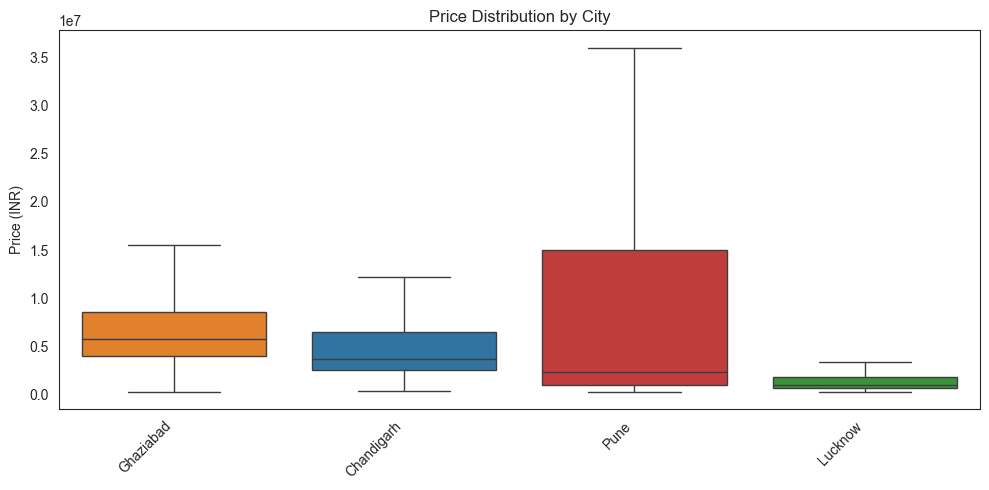

In [14]:
order = df.groupby("city")["price"].median().sort_values(ascending=False).index

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df, x="city", y="price",
    order=order,
    hue="city",
    palette="tab10",
    showfliers=False,
    legend=False
)
plt.title("Price Distribution by City")
plt.ylabel("Price (INR)")
plt.xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig('../reports/figures/price_by_location.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Price by property type

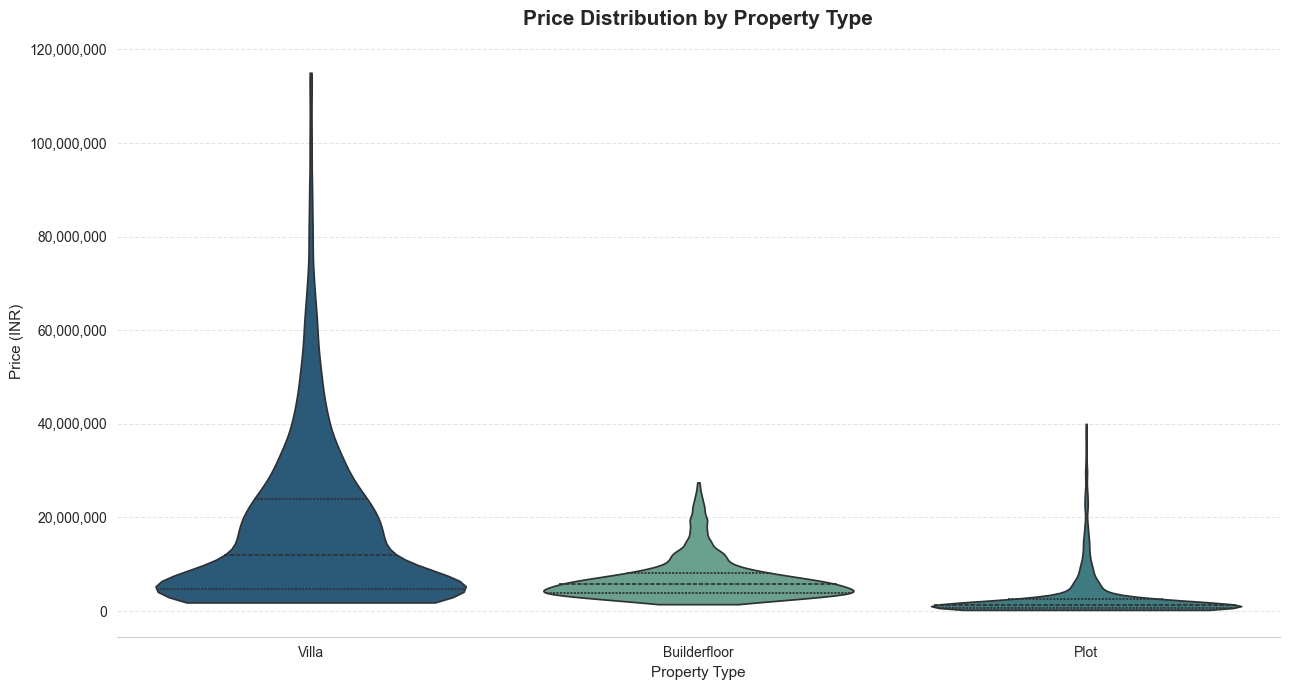

In [15]:
plt.figure(figsize=(13, 7))
sns.set_style("whitegrid")  

order = df.groupby("property_type")["price"].median().sort_values(ascending=False).index

ax = sns.violinplot(
    data=df, x="property_type", y="price",
    order=order,
    hue="property_type",
    palette="crest",
    legend=False,
    inner="quartile",
    cut=0
)

ax.set_title("Price Distribution by Property Type", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Property Type", fontsize=11)
ax.set_ylabel("Price (INR)", fontsize=11)
sns.despine(left=True)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.xaxis.grid(False)
ax.ticklabel_format(style='plain', axis='y')
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('../reports/figures/price_by_property_type.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Price per SqFt - City x Property type

In [16]:
df["price_per_sqft"] = df["price"] / df["area"]
pivot = df.pivot_table(values="price_per_sqft", index="city", columns="property_type", aggfunc="median")
pivot

property_type,Builderfloor,Plot,Villa
city,,,
Chandigarh,3009.708738,2833.333333,4593.253968
Ghaziabad,4827.586207,2444.444444,3888.888889
Lucknow,3954.545455,700.000000,4160.000000
Pune,5327.217125,1000.000000,7801.553206


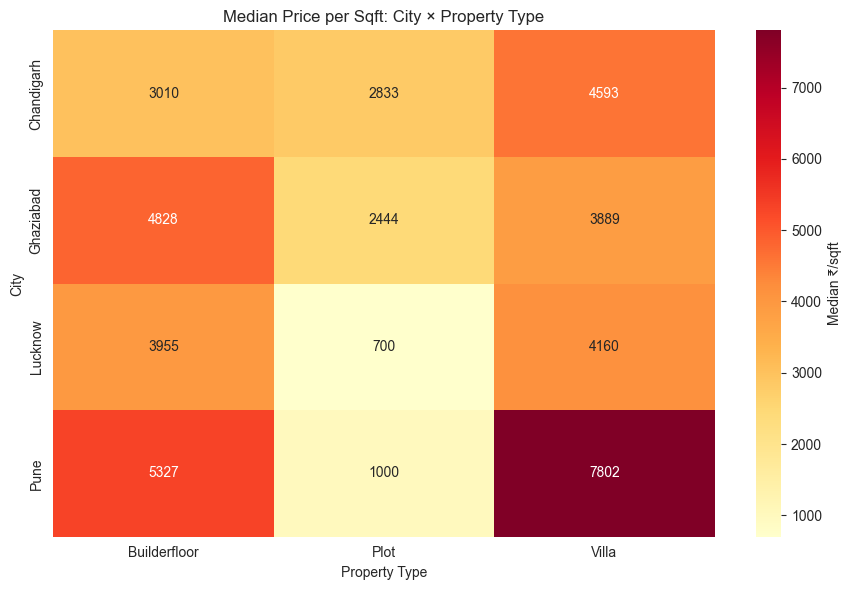

In [17]:
plt.figure(figsize=(9, 6))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    cbar_kws={"label": "Median ₹/sqft"}
)
plt.title("Median Price per Sqft: City × Property Type")
plt.xlabel("Property Type")
plt.ylabel("City")
plt.tight_layout()

plt.savefig('../reports/figures/price_per_sqft.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Price distiribution by New vs Resale

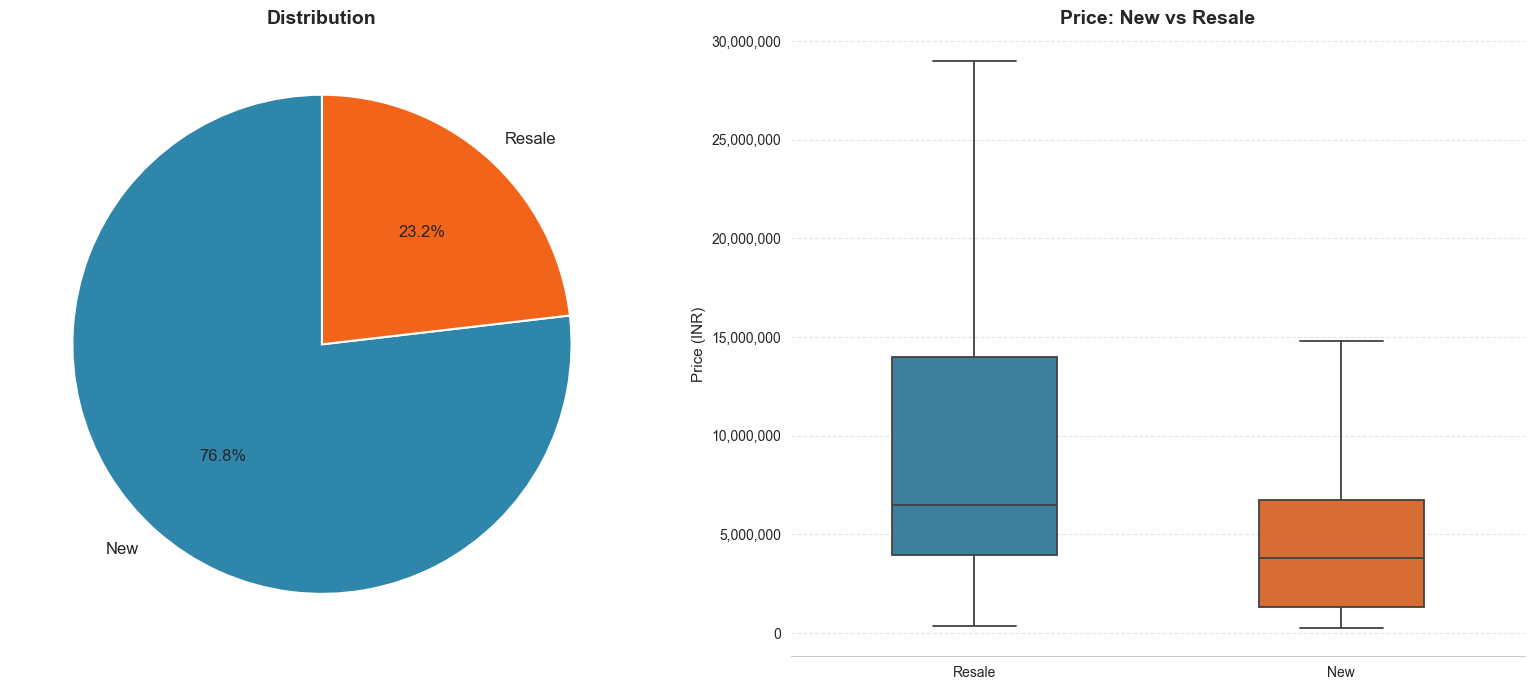

In [18]:

df["new/resale_label"] = df["new/resale"].map({0: "Resale", 1: "New"})  
order = df.groupby("new/resale_label")["price"].median().sort_values(ascending=False).index
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
# Pie chart
counts = df["new/resale_label"].value_counts()
colors = {"New": "#2E86AB", "Resale": "#F26419"}
plot_colors = [colors.get(cat, "#999999") for cat in counts.index]

axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=plot_colors, startangle=90,
            wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'},
            textprops={'fontsize': 12})
axes[0].set_title("Distribution", fontsize=14, fontweight="bold")
# Boxplot
sns.boxplot(
    data=df, x="new/resale_label", y="price", order=order,
    showfliers=False, hue="new/resale_label",
    palette=["#2E86AB", "#F26419"], legend=False,
    width=0.45, linewidth=1.3, ax=axes[1]
)
axes[1].set_title("Price: New vs Resale", fontsize=14, fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Price (INR)", fontsize=11)
sns.despine(ax=axes[1], left=True)
axes[1].yaxis.grid(True, linestyle="--", alpha=0.5)
axes[1].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('../reports/figures/new_vs_resale.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Amenities Count vs Price Distribution


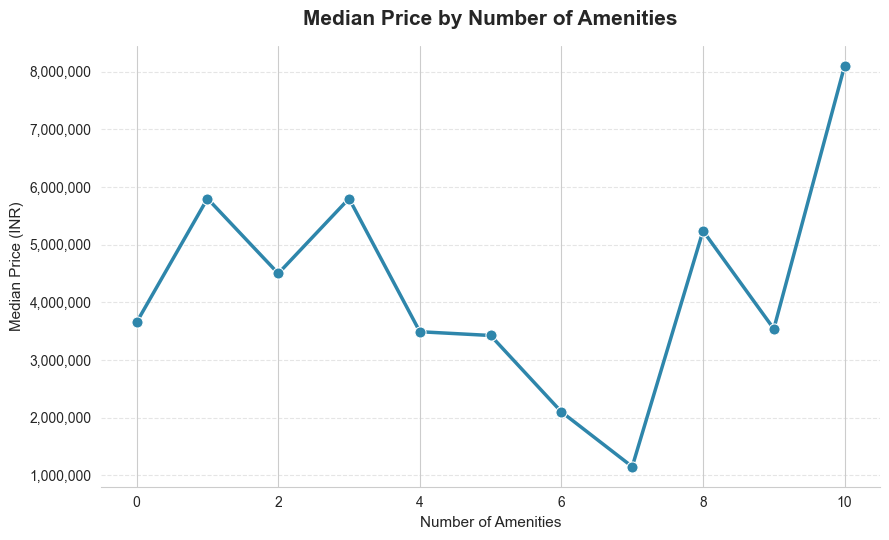

In [19]:
plt.figure(figsize=(9, 5.5))
sns.set_style("whitegrid")

summary = df.groupby("amenity_count")["price"].median().reset_index()

ax = sns.lineplot(
    data=summary, x="amenity_count", y="price",
    marker="o", color="#2E86AB", linewidth=2.5, markersize=8
)

ax.set_title("Median Price by Number of Amenities", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Number of Amenities", fontsize=11)
ax.set_ylabel("Median Price (INR)", fontsize=11)
sns.despine(left=True)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('../reports/figures/amenities_price_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Heatmap (Numeric Features)


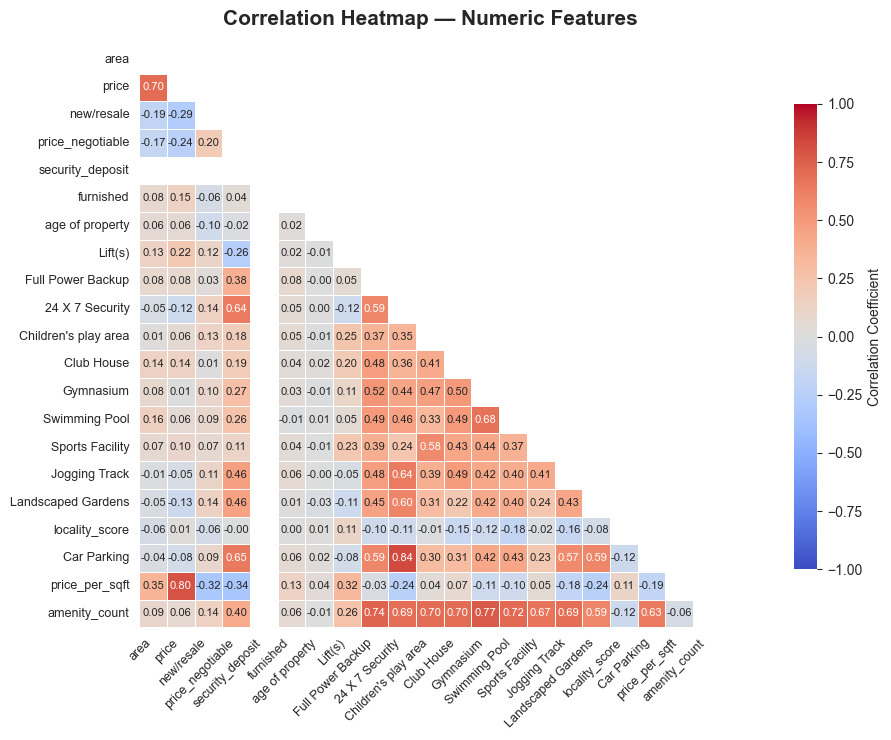

In [20]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()

plt.figure(figsize=(15, 7.5))
sns.set_style("white")

mask = np.triu(np.ones_like(corr, dtype=bool))

ax = sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Correlation Coefficient", "shrink": 0.8},
    square=True,
    vmin=-1, vmax=1
)

ax.set_title("Correlation Heatmap — Numeric Features", fontsize=15, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('../reports/figures/heatmap(numeric features).png', dpi=300, bbox_inches='tight')
plt.show()

## >Key Takeaways from the given graphs

1. Price Distribution
   > Log-transforming price stabilizes variance and outlier influence, aligns the data with linear modeling assumptions, and turns multiplicative price relationships into interpretable, percentage-based coefficients — leading to more accurate and fair predictions across all price ranges.
2. Price by Location
   > Pune shows both the widest price range and the highest whisker (~340M), while all four cities have tightly compressed, heavily right-skewed boxes near zero — indicating a small number of extreme high-priced properties even after excluding outliers.
3. Price by Property Type
   >Villas command the highest and most spread-out prices (median ~1.2Cr, range up to 5.5Cr), while builder floors and plots are progressively cheaper and more tightly clustered.
4. Price per SqFt - City x Property Type
   >Pune has the highest per-sqft prices across the board — especially for villas (₹7,838/sqft) — while plots are consistently the cheapest property type in every city, with Lucknow's plot rate (₹700/sqft) standing out as the overall low.
5. Price Distribution by New vs Resale
   >Properties labeled "No" (likely non-resale/new) have a higher median price (~₹65L) and wider spread than "Yes" (~₹40L), suggesting resale properties tend to be cheaper and more tightly priced.
6. Amenities Count vs Price Distribution
   >Median price shows no strong linear trend with amenity count, but properties with 8+ amenities show much wider price ranges and higher upper bounds, suggesting amenity count matters more for premium-property variance than for typical price level.
7. Heatmap (Numeric Features)
   >Price is most strongly correlated with price_per_sqft (0.68), moderately with area (0.23) and locality_score (0.18), while age of property shows almost no relationship with price (0.06).